<a href="https://colab.research.google.com/github/sindgisrishtis/StyleSyncAI/blob/main/segmentataion_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Original Medical Role Challenge


In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!pip install -q segmentation-models-pytorch
!pip install -q albumentations
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.5 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#data Analysis

In [ ]:
IMAGE_DIR = "/content/drive/MyDrive/Origin_Medical_Challenge/data/task_segmentation_images"

MASK_DIR = "/content/drive/MyDrive/Origin_Medical_Challenge/data/task_segmentation_masks"

In [ ]:
image_files = sorted(os.listdir(IMAGE_DIR))
mask_files = sorted(os.listdir(MASK_DIR))

print(len(image_files))
print(len(mask_files))

622
622


In [ ]:
data = []

for img_name in image_files:

    base = img_name.replace(".png", "")

    mask_name = f"{base}_Annotation.png"

    if mask_name in mask_files:

        data.append([
            img_name,
            mask_name
        ])

df_seg = pd.DataFrame(
    data,
    columns=["image", "mask"]
)

df_seg.head()

,image,mask
0,000_HC.png,000_HC_Annotation.png
1,001_HC.png,001_HC_Annotation.png
2,002_HC.png,002_HC_Annotation.png
3,003_HC.png,003_HC_Annotation.png
4,004_HC.png,004_HC_Annotation.png


In [ ]:
train_df, temp_df = train_test_split(
    df_seg,
    test_size=0.30,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

print(len(train_df))
print(len(val_df))
print(len(test_df))

435
93
94


Data Preprocessing

In [ ]:
train_transform = A.Compose([
    A.Resize(512,512),

    A.HorizontalFlip(p=0.5),

    A.Rotate(
        limit=20,
        p=0.5
    ),

    A.RandomBrightnessContrast(p=0.3),

    ToTensorV2()
])

In [ ]:
val_transform = A.Compose([
    A.Resize(512,512),
    ToTensorV2()
])

In [ ]:
class FetalSegDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = cv2.imread(
            os.path.join(
                IMAGE_DIR,
                row["image"]
            )
        )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        mask = cv2.imread(
            os.path.join(
                MASK_DIR,
                row["mask"]
            ),
            0
        )

        mask = (mask > 0).astype(np.float32)

        if self.transform:

            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented["image"].float() / 255.0
            mask = augmented["mask"].unsqueeze(0)

        return image, mask

#Part B : Segmentation-Based Approach

# Hypothesis 1 : Contour Masks

## Objective

Train a segmentation model directly on the provided contour masks.

## Motivation

The provided annotations contain fetal skull boundary information.
A U-Net architecture with a pretrained ResNet34 encoder is chosen as a strong baseline for medical image segmentation.

## Expected Limitation

Since masks contain only contour pixels and not filled regions, the model may struggle to learn complete object representations.

In [ ]:
train_dataset = FetalSegDataset(
    train_df,
    train_transform
)

val_dataset = FetalSegDataset(
    val_df,
    val_transform
)

test_dataset = FetalSegDataset(
    test_df,
    val_transform
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

## Model Architecture

- U-Net
- ResNet34 Encoder
- ImageNet Pretraining

Reason:
- Small dataset (~622 images)
- Strong transfer learning
- Common medical segmentation baseline

In [ ]:
DEVICE = "cuda"
model = smp.Unet(

    encoder_name="resnet34",

    encoder_weights="imagenet",

    in_channels=3,

    classes=1

)

model.to(DEVICE)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([8, 3, 512, 512])
torch.Size([8, 1, 512, 512])


In [ ]:
dice_loss = smp.losses.DiceLoss(
    mode="binary"
)

bce_loss = nn.BCEWithLogitsLoss()

In [ ]:
def loss_fn(pred, target):

    return (
        dice_loss(pred,target)
        +
        bce_loss(pred,target)
    )

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

In [ ]:
def dice_score(preds, targets, smooth=1e-6):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    intersection = (preds * targets).sum()

    union = preds.sum() + targets.sum()

    dice = (2.0 * intersection + smooth) / (union + smooth)

    return dice.item()

In [ ]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0

    for images, masks in loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [ ]:
def validate(model, loader):

    model.eval()

    running_loss = 0
    running_dice = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)

            loss = loss_fn(outputs, masks)

            running_loss += loss.item()

            running_dice += dice_score(
                outputs,
                masks
            )

    return (
        running_loss / len(loader),
        running_dice / len(loader)
    )

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/Origin_Medical_Challenge/models"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

In [ ]:
NUM_EPOCHS = 20

best_loss = float("inf")

train_losses = []
val_losses = []
val_dices = []

In [ ]:
for epoch in range(NUM_EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_dice = validate(
        model,
        val_loader
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_dices.append(val_dice)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f}"
    )

    print(
        f"Val Dice: {val_dice:.4f}"
    )

    if val_loss < best_loss:

        best_loss = val_loss

        torch.save(
            model.state_dict(),
            os.path.join(
                SAVE_DIR,
                "unet_resnet34_best.pth"
            )
        )

        print("Best model saved")

    print("-"*40)

Epoch 1/20
Train Loss: 1.4741
Val Loss: 1.3257
Val Dice: 0.0337
Best model saved
----------------------------------------
Epoch 2/20
Train Loss: 1.2474
Val Loss: 1.1961
Val Dice: 0.0612
Best model saved
----------------------------------------
Epoch 3/20
Train Loss: 1.1791
Val Loss: 1.1534
Val Dice: 0.1394
Best model saved
----------------------------------------
Epoch 4/20
Train Loss: 1.1377
Val Loss: 1.1198
Val Dice: 0.1822
Best model saved
----------------------------------------
Epoch 5/20
Train Loss: 1.1060
Val Loss: 1.0898
Val Dice: 0.2179
Best model saved
----------------------------------------
Epoch 6/20
Train Loss: 1.0792
Val Loss: 1.0644
Val Dice: 0.2300
Best model saved
----------------------------------------
Epoch 7/20
Train Loss: 1.0547
Val Loss: 1.0384
Val Dice: 0.2398
Best model saved
----------------------------------------
Epoch 8/20
Train Loss: 1.0317
Val Loss: 1.0201
Val Dice: 0.2393
Best model saved
----------------------------------------
Epoch 9/20
Train Loss: 1

## Result Analysis

Validation Dice reached approximately 0.26.

Observation:

The model learns the contour structure but struggles with precise localization.

Potential reason:

The provided annotations are contour-only masks, resulting in a sparse supervision signal.

In [ ]:
mask = cv2.imread(
    os.path.join(
        MASK_DIR,
        mask_files[0]
    ),
    0
)

print(mask.shape)

print(
    np.sum(mask > 0)
)

print(
    mask.shape[0] * mask.shape[1]
)

(540, 800)
1632
432000


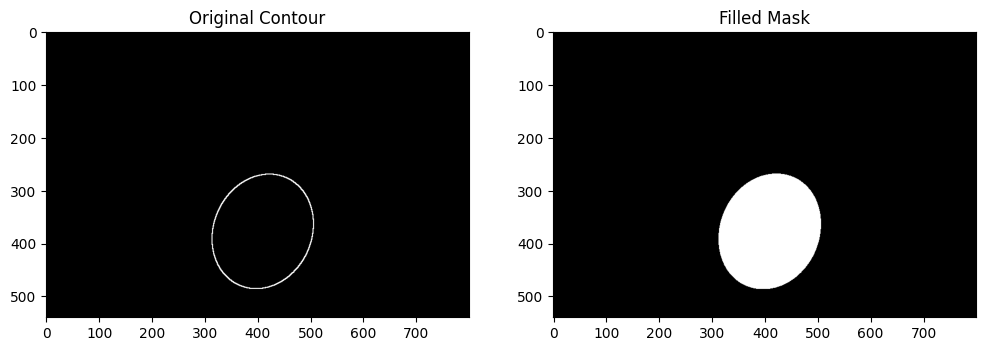

Original pixels: 1632
Filled pixels: 33111


In [ ]:
mask = cv2.imread(
    os.path.join(
        MASK_DIR,
        mask_files[0]
    ),
    0
)

contours, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

filled = np.zeros_like(mask)

cv2.drawContours(
    filled,
    contours,
    -1,
    255,
    thickness=cv2.FILLED
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(mask,cmap="gray")
plt.title("Original Contour")

plt.subplot(1,2,2)
plt.imshow(filled,cmap="gray")
plt.title("Filled Mask")

plt.show()

print("Original pixels:", np.sum(mask>0))
print("Filled pixels:", np.sum(filled>0))

In [ ]:
mask_folder = "/content/drive/MyDrive/Origin_Medical_Challenge/data/task_segmentation_masks"

FILLED_MASK_DIR = "/content/drive/MyDrive/Origin_Medical_Challenge/data/task_segmentation_filled_masks"

import os
os.makedirs(FILLED_MASK_DIR, exist_ok=True)

Total masks: 622
['000_HC_Annotation.png', '001_HC_Annotation.png', '002_HC_Annotation.png', '003_HC_Annotation.png', '004_HC_Annotation.png']


In [ ]:
import cv2
import numpy as np
from tqdm import tqdm

masks = sorted(os.listdir(mask_folder))

for mask_name in tqdm(masks):

    mask = cv2.imread(
        os.path.join(mask_folder, mask_name),
        0
    )

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    filled = np.zeros_like(mask)

    cv2.drawContours(
        filled,
        contours,
        -1,
        255,
        thickness=cv2.FILLED
    )

    cv2.imwrite(
        os.path.join(FILLED_MASK_DIR, mask_name),
        filled
    )

print("Filled masks generated.")

100%|██████████| 622/622 [00:12<00:00, 49.85it/s]

Filled masks generated.


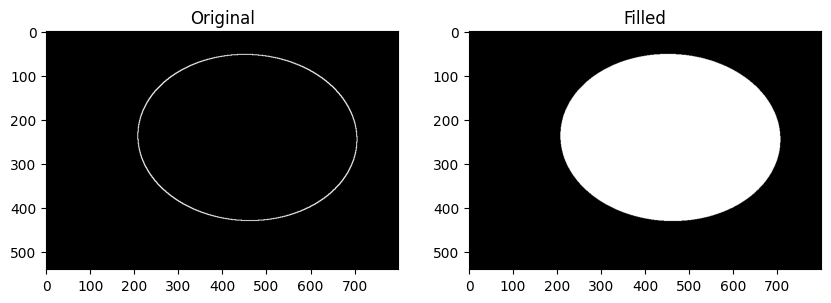

In [ ]:
import random
import matplotlib.pyplot as plt

sample = random.choice(masks)

original = cv2.imread(
    os.path.join(mask_folder, sample),
    0
)

filled = cv2.imread(
    os.path.join(FILLED_MASK_DIR, sample),
    0
)

fig, ax = plt.subplots(1,2,figsize=(10,5))

ax[0].imshow(original,cmap="gray")
ax[0].set_title("Original")

ax[1].imshow(filled,cmap="gray")
ax[1].set_title("Filled")

plt.show()

# Hypothesis 2 : Filled Masks

## Filled Ellipse Masks

Observation from Hypothesis 1:

The contour masks occupy less than 1% of image pixels.

This causes severe class imbalance.

Hypothesis:

Converting contour annotations into filled masks will provide stronger supervision and improve segmentation quality.

In [ ]:
print(df_seg.head())
print(df_seg.columns)

        image                   mask
0  000_HC.png  000_HC_Annotation.png
1  001_HC.png  001_HC_Annotation.png
2  002_HC.png  002_HC_Annotation.png
3  003_HC.png  003_HC_Annotation.png
4  004_HC.png  004_HC_Annotation.png
Index(['image', 'mask'], dtype='object')


In [ ]:
class FetalSegDatasetH2(Dataset):

    def __init__(
        self,
        dataframe,
        mask_dir,
        transform=None
    ):

        self.df = dataframe
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = cv2.imread(
            os.path.join(
                IMAGE_DIR,
                row["image"]
            )
        )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        mask = cv2.imread(
            os.path.join(
                self.mask_dir,
                row["mask"]
            ),
            0
        )

        mask = (mask > 0).astype(np.float32)

        if self.transform:

            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented["image"].float() / 255.0
            mask = augmented["mask"].unsqueeze(0)

        return image, mask

In [ ]:
FILLED_MASK_DIR = "/content/drive/MyDrive/Origin_Medical_Challenge/data/task_segmentation_filled_masks"

In [ ]:
train_dataset_h2 = FetalSegDatasetH2(
    train_df,
    FILLED_MASK_DIR,
    train_transform
)

val_dataset_h2 = FetalSegDatasetH2(
    val_df,
    FILLED_MASK_DIR,
    val_transform
)

test_dataset_h2 = FetalSegDatasetH2(
    test_df,
    FILLED_MASK_DIR,
    val_transform
)

In [ ]:
train_loader_h2 = DataLoader(
    train_dataset_h2,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

val_loader_h2 = DataLoader(
    val_dataset_h2,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

In [ ]:
images, masks = next(iter(train_loader_h2))

print(images.shape)
print(masks.shape)

print("Min:", masks.min())
print("Max:", masks.max())
print("Mean:", masks.float().mean())

torch.Size([8, 3, 512, 512])
torch.Size([8, 1, 512, 512])
Min: tensor(0.)
Max: tensor(1.)
Mean: tensor(0.2758)


In [ ]:
model_h2 = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model_h2.to(DEVICE)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

## Model Architecture

A U-Net architecture with a ResNet34 encoder backbone was selected for the segmentation task.

Reasons for selection:

- Strong performance on medical image segmentation tasks.
- Efficient use of skip connections for preserving spatial information.
- Availability of ImageNet pretrained weights for transfer learning.
- Good balance between accuracy and computational efficiency.

Configuration:

- Architecture: U-Net
- Encoder: ResNet34
- Encoder Weights: ImageNet
- Input Channels: 3
- Output Classes: 1

In [ ]:
dice_loss_h2 = smp.losses.DiceLoss(
    mode="binary"
)

bce_loss_h2 = nn.BCEWithLogitsLoss()

def loss_fn_h2(pred, target):

    return (
        dice_loss_h2(pred, target)
        +
        bce_loss_h2(pred, target)
    )

In [ ]:
optimizer_h2 = torch.optim.AdamW(
    model_h2.parameters(),
    lr=1e-4
)

In [ ]:
def train_one_epoch_generic(
    model,
    loader,
    optimizer,
    loss_function
):

    model.train()

    running_loss = 0

    for images, masks in loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_function(
            outputs,
            masks
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [ ]:
def validate_generic(
    model,
    loader,
    loss_function
):

    model.eval()

    running_loss = 0
    running_dice = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)

            loss = loss_function(
                outputs,
                masks
            )

            running_loss += loss.item()

            running_dice += dice_score(
                outputs,
                masks
            )

    return (
        running_loss / len(loader),
        running_dice / len(loader)
    )

In [ ]:
NUM_EPOCHS = 20

best_loss_h2 = float("inf")

train_losses_h2 = []
val_losses_h2 = []
val_dices_h2 = []

## Experimental Setup

Training Configuration:

- Input Resolution: 512 × 512
- Batch Size: 8
- Optimizer: AdamW
- Learning Rate: 1e-4
- Epochs: 20

Loss Function:

A combination of Dice Loss and Binary Cross Entropy (BCE) Loss was used.

Total Loss:

Loss = Dice Loss + BCE Loss

Evaluation Metric:

- Dice Similarity Coefficient (DSC)

Dataset Split:

- Training Set: 70%
- Validation Set: 15%
- Test Set: 15%

Random Seed: 42

In [ ]:
for epoch in range(NUM_EPOCHS):

    train_loss = train_one_epoch_generic(
        model_h2,
        train_loader_h2,
        optimizer_h2,
        loss_fn_h2
    )

    val_loss, val_dice = validate_generic(
        model_h2,
        val_loader_h2,
        loss_fn_h2
    )

    train_losses_h2.append(train_loss)
    val_losses_h2.append(val_loss)
    val_dices_h2.append(val_dice)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f}"
    )

    print(
        f"Val Dice: {val_dice:.4f}"
    )

    if val_loss < best_loss_h2:

        best_loss_h2 = val_loss

        torch.save(
            model_h2.state_dict(),
            os.path.join(
                SAVE_DIR,
                "hypothesis2_filledmask_unet_resnet34.pth"
            )
        )

        print("Best H2 model saved")

    print("-"*40)

Epoch 1/20
Train Loss: 0.6733
Val Loss: 0.3894
Val Dice: 0.9376
Best H2 model saved
----------------------------------------
Epoch 2/20
Train Loss: 0.3431
Val Loss: 0.2939
Val Dice: 0.9542
Best H2 model saved
----------------------------------------
Epoch 3/20
Train Loss: 0.2521
Val Loss: 0.2336
Val Dice: 0.9606
Best H2 model saved
----------------------------------------
Epoch 4/20
Train Loss: 0.1929
Val Loss: 0.2236
Val Dice: 0.9521
Best H2 model saved
----------------------------------------
Epoch 5/20
Train Loss: 0.1628
Val Loss: 0.1805
Val Dice: 0.9617
Best H2 model saved
----------------------------------------
Epoch 6/20
Train Loss: 0.1466
Val Loss: 0.1659
Val Dice: 0.9594
Best H2 model saved
----------------------------------------
Epoch 7/20
Train Loss: 0.1318
Val Loss: 0.1531
Val Dice: 0.9633
Best H2 model saved
----------------------------------------
Epoch 8/20
Train Loss: 0.1189
Val Loss: 0.1899
Val Dice: 0.9469
----------------------------------------
Epoch 9/20
Train Los

## Results

The filled-mask strategy produced a substantial improvement over the contour-mask baseline.

Hypothesis 1 (Contour Masks):

- Validation Dice ≈ 0.26

Hypothesis 2 (Filled Masks):

- Best Validation Dice ≈ 0.97
- Test Dice ≈ 0.977

The model successfully learned the complete fetal skull shape and generated accurate segmentation masks across the test set.

Visual inspection showed strong agreement between ground-truth masks and predicted masks.

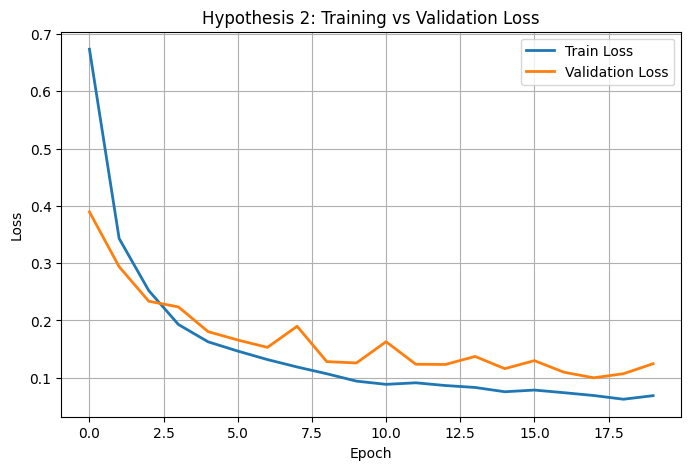

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_losses_h2,
    label="Train Loss",
    linewidth=2
)

plt.plot(
    val_losses_h2,
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Hypothesis 2: Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "H2_loss_curve.png"
    ),
    bbox_inches="tight",
    dpi=300
)

plt.show()

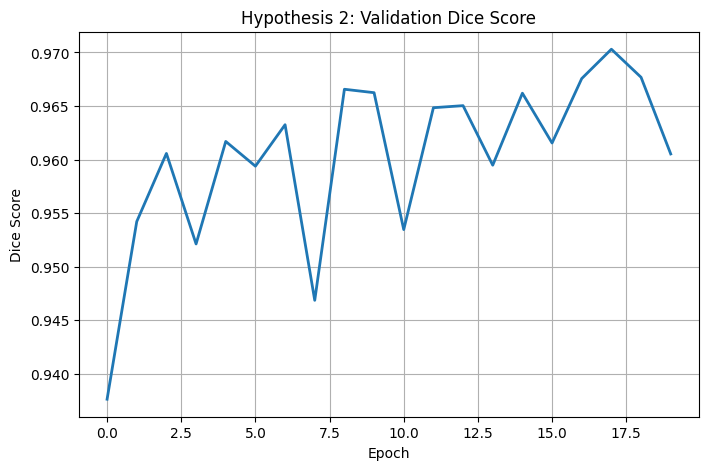

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    val_dices_h2,
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Hypothesis 2: Validation Dice Score")

plt.grid(True)

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "H2_dice_curve.png"
    ),
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [ ]:
model_h2.load_state_dict(
    torch.load(
        os.path.join(
            SAVE_DIR,
            "hypothesis2_filledmask_unet_resnet34.pth"
        )
    )
)

model_h2.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

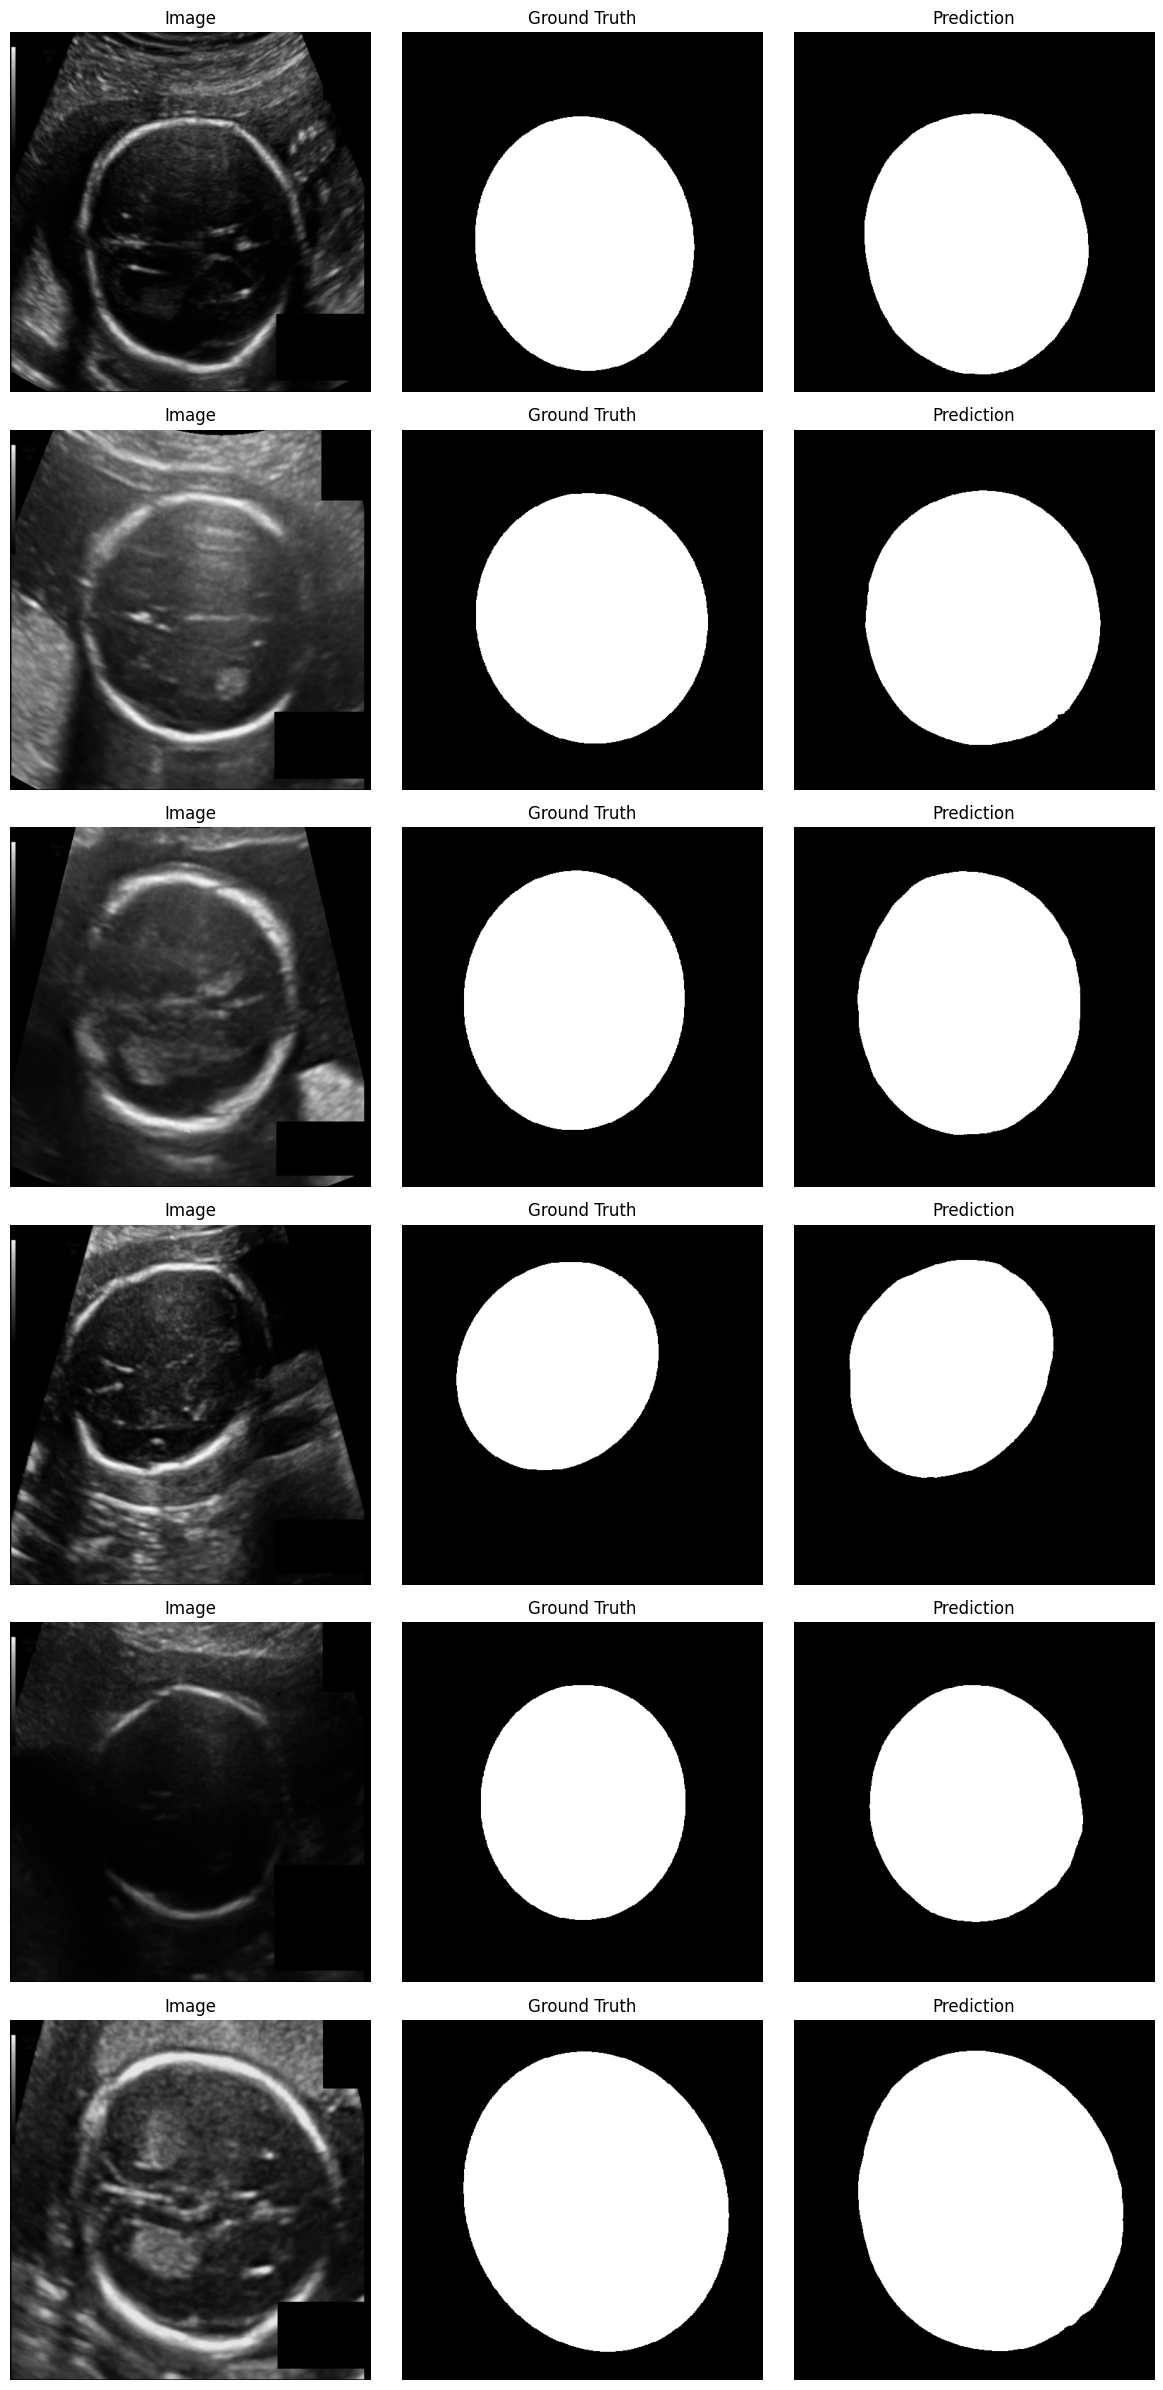

In [ ]:
import random

sample_ids = random.sample(
    range(len(test_dataset_h2)),
    6
)

fig, axes = plt.subplots(
    6,
    3,
    figsize=(12,24)
)

for row_idx, idx in enumerate(sample_ids):

    image, mask = test_dataset_h2[idx]

    with torch.no_grad():

        pred = model_h2(
            image.unsqueeze(0).to(DEVICE)
        )

        pred = torch.sigmoid(pred)

        pred = (
            pred > 0.5
        ).float()

    image_np = (
        image.permute(1,2,0)
        .cpu()
        .numpy()
    )

    mask_np = (
        mask.squeeze()
        .cpu()
        .numpy()
    )

    pred_np = (
        pred.squeeze()
        .cpu()
        .numpy()
    )

    axes[row_idx,0].imshow(image_np)
    axes[row_idx,0].set_title("Image")
    axes[row_idx,0].axis("off")

    axes[row_idx,1].imshow(
        mask_np,
        cmap="gray"
    )
    axes[row_idx,1].set_title("Ground Truth")
    axes[row_idx,1].axis("off")

    axes[row_idx,2].imshow(
        pred_np,
        cmap="gray"
    )
    axes[row_idx,2].set_title("Prediction")
    axes[row_idx,2].axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "H2_predictions.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
test_loader_h2 = DataLoader(
    test_dataset_h2,
    batch_size=8,
    shuffle=False
)

In [ ]:
test_loss, test_dice = validate_generic(
    model_h2,
    test_loader_h2,
    loss_fn_h2
)

print("Test Loss:", test_loss)
print("Test Dice:", test_dice)

Test Loss: 0.0719365489979585
Test Dice: 0.9770640631516775


In [ ]:
import pandas as pd

results_df = pd.DataFrame({

    "Hypothesis":[
        "H1 Contour Masks",
        "H2 Filled Masks"
    ],

    "Validation Dice":[
        0.26,
        max(val_dices_h2)
    ]
})

results_df

,Hypothesis,Validation Dice
0,H1 Contour Masks,0.260000
1,H2 Filled Masks,0.970299


In [ ]:
results_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "segmentation_results.csv"
    ),
    index=False
)

# Hypothesis 3

## Ellipse-based Biometry Extraction

Observation from Hypothesis 2:

The segmentation model accurately predicts the fetal skull region with a validation Dice score above 0.97.

Hypothesis:

If a robust ellipse is fitted to the predicted skull mask, the major and minor axes of the ellipse can be used to automatically derive OFD and BPD landmark points.

Expected Benefit:

- Converts segmentation output into clinically meaningful biometric measurements.
- Provides explainable landmark extraction.
- Eliminates need for direct landmark regression.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
image, mask = test_dataset_h2[0]

with torch.no_grad():

    pred = model_h2(
        image.unsqueeze(0).to(DEVICE)
    )

pred = torch.sigmoid(pred)

pred = (
    pred > 0.5
).float()

pred_mask = (
    pred.squeeze()
    .cpu()
    .numpy()
    .astype(np.uint8)
)

pred_mask *= 255

In [ ]:
contours, _ = cv2.findContours(
    pred_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

cnt = max(
    contours,
    key=cv2.contourArea
)

ellipse = cv2.fitEllipse(cnt)

print(ellipse)

((233.3140106201172, 274.7489929199219), (349.87286376953125, 422.8823547363281), 11.092464447021484)


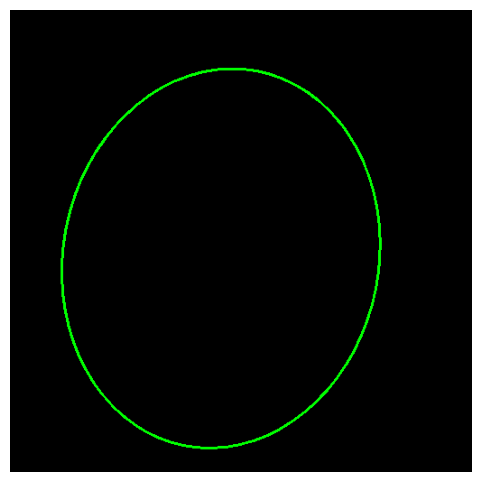

In [ ]:
canvas = np.zeros(
    (*pred_mask.shape,3),
    dtype=np.uint8
)

cv2.ellipse(
    canvas,
    ellipse,
    (0,255,0),
    2
)

plt.figure(figsize=(6,6))
plt.imshow(canvas)
plt.axis("off")
plt.show()

In [ ]:
(center_x, center_y), (axis1, axis2), angle = ellipse

print("Center X:", center_x)
print("Center Y:", center_y)

print("Axis 1:", axis1)
print("Axis 2:", axis2)

print("Angle:", angle)

Center X: 233.3140106201172
Center Y: 274.7489929199219
Axis 1: 349.87286376953125
Axis 2: 422.8823547363281
Angle: 11.092464447021484


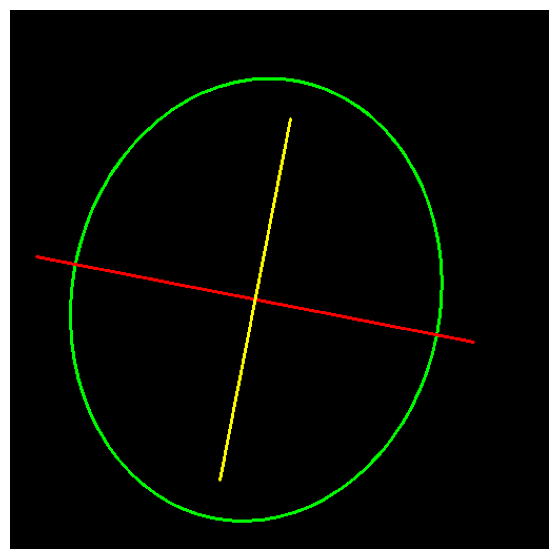

In [ ]:
import math

(center_x, center_y), (axis1, axis2), angle = ellipse

canvas = np.zeros(
    (*pred_mask.shape, 3),
    dtype=np.uint8
)

cv2.ellipse(
    canvas,
    ellipse,
    (0,255,0),
    2
)

theta = np.radians(angle)

major = max(axis1, axis2) / 2
minor = min(axis1, axis2) / 2

x1 = int(center_x + major*np.cos(theta))
y1 = int(center_y + major*np.sin(theta))

x2 = int(center_x - major*np.cos(theta))
y2 = int(center_y - major*np.sin(theta))

x3 = int(center_x + minor*np.cos(theta + np.pi/2))
y3 = int(center_y + minor*np.sin(theta + np.pi/2))

x4 = int(center_x - minor*np.cos(theta + np.pi/2))
y4 = int(center_y - minor*np.sin(theta + np.pi/2))

cv2.line(canvas,(x1,y1),(x2,y2),(255,0,0),2)
cv2.line(canvas,(x3,y3),(x4,y4),(255,255,0),2)

plt.figure(figsize=(7,7))
plt.imshow(canvas)
plt.axis("off")
plt.show()

## Results

The segmentation output was successfully converted into an ellipse representation using OpenCV ellipse fitting.

Example ellipse parameters:

- Center: (233.31, 274.75)
- Major Axis (OFD): 422.88 pixels
- Minor Axis (BPD): 349.87 pixels
- Orientation: 11.09°

The extracted ellipse closely matched the predicted skull contour, demonstrating that geometric fetal biometrics can be derived directly from segmentation outputs.

This provides a complete pipeline from image → segmentation → ellipse fitting → biometric extraction.

## Analysis

The fitted ellipse accurately captures the global geometry of the fetal skull.

Unlike direct landmark regression, ellipse fitting provides an interpretable geometric representation of the anatomy.

The major and minor ellipse axes naturally correspond to OFD and BPD measurements, making the approach clinically meaningful and easier to validate.

This strategy also reduces sensitivity to local prediction noise because measurements are derived from the entire segmented structure rather than individual predicted points.

# Part B: Biometry Extraction from Segmentation

Using the predicted cranial mask, an ellipse is fitted to the segmented contour.

The major and minor axes of the ellipse are used to estimate:

- Occipitofrontal Diameter (OFD)
- Biparietal Diameter (BPD)

This converts the segmentation output into clinically relevant fetal head biometrics.

In [ ]:
model.load_state_dict(
    torch.load(
        os.path.join(
            SAVE_DIR,
            "unet_resnet34_best.pth"
        )
    )
)

model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
image, mask = test_dataset_h2[0]

with torch.no_grad():

    pred = model(
        image.unsqueeze(0).to(DEVICE)
    )

pred = torch.sigmoid(pred)

pred = (pred > 0.5).float()

pred_mask = pred.squeeze().cpu().numpy().astype(np.uint8)

In [ ]:
contours, _ = cv2.findContours(
    pred_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

cnt = max(
    contours,
    key=cv2.contourArea
)

ellipse = cv2.fitEllipse(cnt)

In [ ]:
(center_x, center_y), (axis1, axis2), angle = ellipse

print("Center:", center_x, center_y)

print("Axis1:", axis1)

print("Axis2:", axis2)

print("Angle:", angle)

Center: 257.5230712890625 310.97283935546875
Axis1: 379.9192810058594
Axis2: 497.3866271972656
Angle: 168.6484832763672


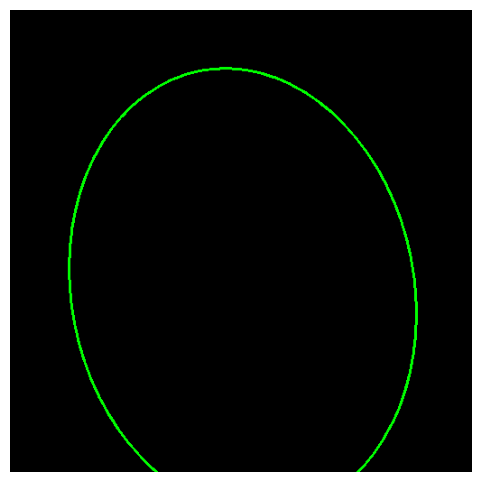

In [ ]:
canvas = np.zeros(
    (512,512,3),
    dtype=np.uint8
)
cv2.ellipse(
    canvas,
    ellipse,
    (0,255,0),
    2
)

plt.figure(figsize=(6,6))
plt.imshow(canvas)
plt.axis("off")
plt.show()

In [ ]:
import math

(center_x, center_y), (axis1, axis2), angle = ellipse

theta = np.deg2rad(angle)

major = max(axis1, axis2)
minor = min(axis1, axis2)

dx_major = (major / 2) * np.cos(theta)
dy_major = (major / 2) * np.sin(theta)

dx_minor = (minor / 2) * np.cos(theta + np.pi/2)
dy_minor = (minor / 2) * np.sin(theta + np.pi/2)

In [ ]:
pt1_major = (
    int(center_x - dx_major),
    int(center_y - dy_major)
)

pt2_major = (
    int(center_x + dx_major),
    int(center_y + dy_major)
)

In [ ]:
pt1_minor = (
    int(center_x - dx_minor),
    int(center_y - dy_minor)
)

pt2_minor = (
    int(center_x + dx_minor),
    int(center_y + dy_minor)
)

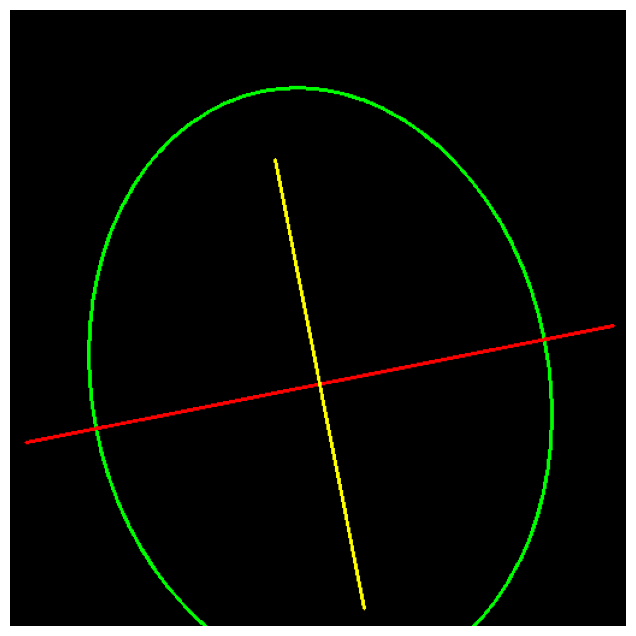

In [ ]:
cv2.line(
    canvas,
    pt1_major,
    pt2_major,
    (255,0,0),
    2
)

cv2.line(
    canvas,
    pt1_minor,
    pt2_minor,
    (255,255,0),
    2
)

plt.figure(figsize=(8,8))
plt.imshow(canvas)
plt.axis("off")
plt.show()

In [ ]:
print("Estimated OFD:", major)
print("Estimated BPD:", minor)

Estimated OFD: 497.3866271972656
Estimated BPD: 379.9192810058594


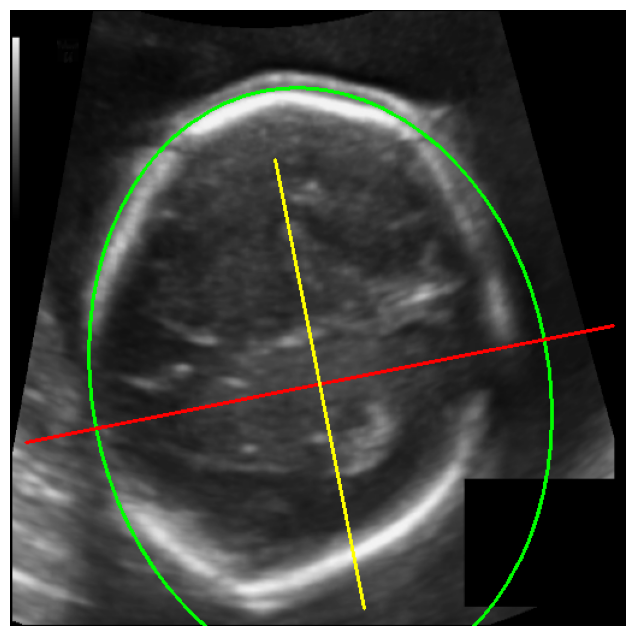

In [ ]:
img = image.permute(1,2,0).cpu().numpy()

overlay = (img * 255).astype(np.uint8).copy()

cv2.ellipse(
    overlay,
    ellipse,
    (0,255,0),
    2
)

cv2.line(
    overlay,
    pt1_major,
    pt2_major,
    (255,0,0),
    2
)

cv2.line(
    overlay,
    pt1_minor,
    pt2_minor,
    (255,255,0),
    2
)

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.axis("off")
plt.show()

# Part A: Landmark Detection-Based Approach

## Hypothesis A1

Direct Landmark Regression using ResNet18

Objective:

Predict OFD and BPD landmark coordinates directly from fetal ultrasound images.

Output:

8 normalized coordinates representing:

- OFD Point 1
- OFD Point 2
- BPD Point 1
- BPD Point 2

In [ ]:
BASE_PATH = "/content/drive/MyDrive/Origin_Medical_Challenge/data"
import pandas as pd
import os

LANDMARK_CSV_PATH = os.path.join(
    BASE_PATH,
    "role_challenge_dataset_ground_truth.csv"
)

landmark_df = pd.read_csv(
    LANDMARK_CSV_PATH
)

print("Shape:", landmark_df.shape)

print("\nColumns:")
print(list(landmark_df.columns))

display(landmark_df.head())

Shape: (622, 9)

Columns:
['image_name', 'ofd_1_x', 'ofd_1_y', 'ofd_2_x', 'ofd_2_y', 'bpd_1_x', 'bpd_1_y', 'bpd_2_x', 'bpd_2_y']


,image_name,ofd_1_x,ofd_1_y,ofd_2_x,ofd_2_y,bpd_1_x,bpd_1_y,bpd_2_x,bpd_2_y
0,000_HC.png,361,12,339,530,481,16,664,318
1,001_HC.png,441,331,368,308,297,247,534,142
2,002_HC.png,318,374,154,406,481,158,558,215
3,003_HC.png,424,105,407,462,305,349,547,363
4,004_HC.png,300,277,611,534,53,452,494,308


In [ ]:
LANDMARK_IMAGE_DIR = "/content/drive/MyDrive/Origin_Medical_Challenge/data/task_landmark_images"

IMAGE_WIDTH = 800
IMAGE_HEIGHT = 540

LANDMARK_COLUMNS = [
    "ofd_1_x",
    "ofd_1_y",
    "ofd_2_x",
    "ofd_2_y",
    "bpd_1_x",
    "bpd_1_y",
    "bpd_2_x",
    "bpd_2_y"
]

In [ ]:
landmark_df_norm = landmark_df.copy()

landmark_df_norm["ofd_1_x"] /= IMAGE_WIDTH
landmark_df_norm["ofd_2_x"] /= IMAGE_WIDTH
landmark_df_norm["bpd_1_x"] /= IMAGE_WIDTH
landmark_df_norm["bpd_2_x"] /= IMAGE_WIDTH

landmark_df_norm["ofd_1_y"] /= IMAGE_HEIGHT
landmark_df_norm["ofd_2_y"] /= IMAGE_HEIGHT
landmark_df_norm["bpd_1_y"] /= IMAGE_HEIGHT
landmark_df_norm["bpd_2_y"] /= IMAGE_HEIGHT

landmark_df_norm.head()

,image_name,ofd_1_x,ofd_1_y,ofd_2_x,ofd_2_y,bpd_1_x,bpd_1_y,bpd_2_x,bpd_2_y
0,000_HC.png,0.45125,0.022222,0.42375,0.981481,0.60125,0.029630,0.83000,0.588889
1,001_HC.png,0.55125,0.612963,0.46000,0.570370,0.37125,0.457407,0.66750,0.262963
2,002_HC.png,0.39750,0.692593,0.19250,0.751852,0.60125,0.292593,0.69750,0.398148
3,003_HC.png,0.53000,0.194444,0.50875,0.855556,0.38125,0.646296,0.68375,0.672222
4,004_HC.png,0.37500,0.512963,0.76375,0.988889,0.06625,0.837037,0.61750,0.570370


In [ ]:
from sklearn.model_selection import train_test_split

train_df_lm, temp_df_lm = train_test_split(
    landmark_df_norm,
    test_size=0.30,
    random_state=42
)

val_df_lm, test_df_lm = train_test_split(
    temp_df_lm,
    test_size=0.50,
    random_state=42
)

print(len(train_df_lm))
print(len(val_df_lm))
print(len(test_df_lm))

435
93
94


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

landmark_train_transform = A.Compose([
    A.Resize(512,512),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    ToTensorV2()
])

landmark_val_transform = A.Compose([
    A.Resize(512,512),
    ToTensorV2()
])

In [ ]:
from torch.utils.data import Dataset
import cv2
import numpy as np
import os

class LandmarkDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = cv2.imread(
            os.path.join(
                LANDMARK_IMAGE_DIR,
                row["image_name"]
            )
        )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        landmarks = row[
            LANDMARK_COLUMNS
        ].values.astype(np.float32)

        if self.transform:

            image = self.transform(
                image=image
            )["image"]

        image = image.float() / 255.0

        landmarks = torch.tensor(
            landmarks,
            dtype=torch.float32
        )

        return image, landmarks

In [ ]:
train_dataset_lm = LandmarkDataset(
    train_df_lm,
    landmark_train_transform
)

val_dataset_lm = LandmarkDataset(
    val_df_lm,
    landmark_val_transform
)

test_dataset_lm = LandmarkDataset(
    test_df_lm,
    landmark_val_transform
)

In [ ]:
from torch.utils.data import DataLoader

train_loader_lm = DataLoader(
    train_dataset_lm,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader_lm = DataLoader(
    val_dataset_lm,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

test_loader_lm = DataLoader(
    test_dataset_lm,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

In [ ]:
images, landmarks = next(
    iter(train_loader_lm)
)

print(images.shape)
print(landmarks.shape)

print(landmarks[0])

torch.Size([16, 3, 512, 512])
torch.Size([16, 8])
tensor([0.2537, 0.9537, 0.7125, 0.6222, 0.3388, 0.4944, 0.5000, 0.0500])


## Model Architecture

A ResNet18 backbone pretrained on ImageNet is used for direct landmark regression.

Input:
- 512 × 512 ultrasound image

Output:
- 8 normalized coordinates

Advantages:
- Small and efficient
- Good transfer learning backbone
- Suitable for limited datasets

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

In [ ]:
class LandmarkResNet18(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )

        in_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Sequential(

            nn.Linear(
                in_features,
                512
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                512,
                8
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        return self.backbone(x)

In [ ]:
model_lm = LandmarkResNet18()

model_lm.to(DEVICE)

print(model_lm)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 98.6MB/s]


LandmarkResNet18(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True,

In [ ]:
loss_fn_lm = nn.SmoothL1Loss()
optimizer_lm = torch.optim.AdamW(
    model_lm.parameters(),
    lr=1e-4
)
def landmark_error(preds, targets):

    preds = preds.reshape(-1,4,2)

    targets = targets.reshape(-1,4,2)

    error = torch.norm(
        preds-targets,
        dim=2
    )

    return error.mean().item()

In [ ]:
def train_one_epoch_lm():

    model_lm.train()

    running_loss = 0

    for images, landmarks in train_loader_lm:

        images = images.to(DEVICE)

        landmarks = landmarks.to(DEVICE)

        optimizer_lm.zero_grad()

        preds = model_lm(images)

        loss = loss_fn_lm(
            preds,
            landmarks
        )

        loss.backward()

        optimizer_lm.step()

        running_loss += loss.item()

    return running_loss / len(train_loader_lm)

In [ ]:
def validate_lm():

    model_lm.eval()

    running_loss = 0
    running_error = 0

    with torch.no_grad():

        for images, landmarks in val_loader_lm:

            images = images.to(DEVICE)

            landmarks = landmarks.to(DEVICE)

            preds = model_lm(images)

            loss = loss_fn_lm(
                preds,
                landmarks
            )

            running_loss += loss.item()

            running_error += landmark_error(
                preds,
                landmarks
            )

    return (

        running_loss / len(val_loader_lm),

        running_error / len(val_loader_lm)
    )

In [ ]:
NUM_EPOCHS_LM = 20

best_loss_lm = float("inf")

train_losses_lm = []

val_losses_lm = []

val_errors_lm = []

In [ ]:
for epoch in range(NUM_EPOCHS_LM):

    train_loss = train_one_epoch_lm()

    val_loss, val_error = validate_lm()

    train_losses_lm.append(
        train_loss
    )

    val_losses_lm.append(
        val_loss
    )

    val_errors_lm.append(
        val_error
    )

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS_LM}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f}"
    )

    print(
        f"Val Error: {val_error:.4f}"
    )

    if val_loss < best_loss_lm:

        best_loss_lm = val_loss

        torch.save(
            model_lm.state_dict(),
            os.path.join(
                SAVE_DIR,
                "landmark_resnet18_best.pth"
            )
        )

        print("Best model saved")

    print("-"*40)

Epoch 1/20
Train Loss: 0.0108
Val Loss: 0.0095
Val Error: 0.1441
Best model saved
----------------------------------------
Epoch 2/20
Train Loss: 0.0077
Val Loss: 0.0088
Val Error: 0.1405
Best model saved
----------------------------------------
Epoch 3/20
Train Loss: 0.0073
Val Loss: 0.0084
Val Error: 0.1358
Best model saved
----------------------------------------
Epoch 4/20
Train Loss: 0.0066
Val Loss: 0.0090
Val Error: 0.1432
----------------------------------------
Epoch 5/20
Train Loss: 0.0060
Val Loss: 0.0083
Val Error: 0.1350
Best model saved
----------------------------------------
Epoch 6/20
Train Loss: 0.0057
Val Loss: 0.0085
Val Error: 0.1365
----------------------------------------
Epoch 7/20
Train Loss: 0.0047
Val Loss: 0.0085
Val Error: 0.1380
----------------------------------------
Epoch 8/20
Train Loss: 0.0040
Val Loss: 0.0089
Val Error: 0.1426
----------------------------------------
Epoch 9/20
Train Loss: 0.0041
Val Loss: 0.0100
Val Error: 0.1479
-------------------

In [ ]:
model_lm.load_state_dict(
    torch.load(
        os.path.join(
            SAVE_DIR,
            "landmark_resnet18_best.pth"
        )
    )
)

model_lm.eval()

LandmarkResNet18(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True,

In [ ]:
import matplotlib.pyplot as plt
import random
import numpy as np

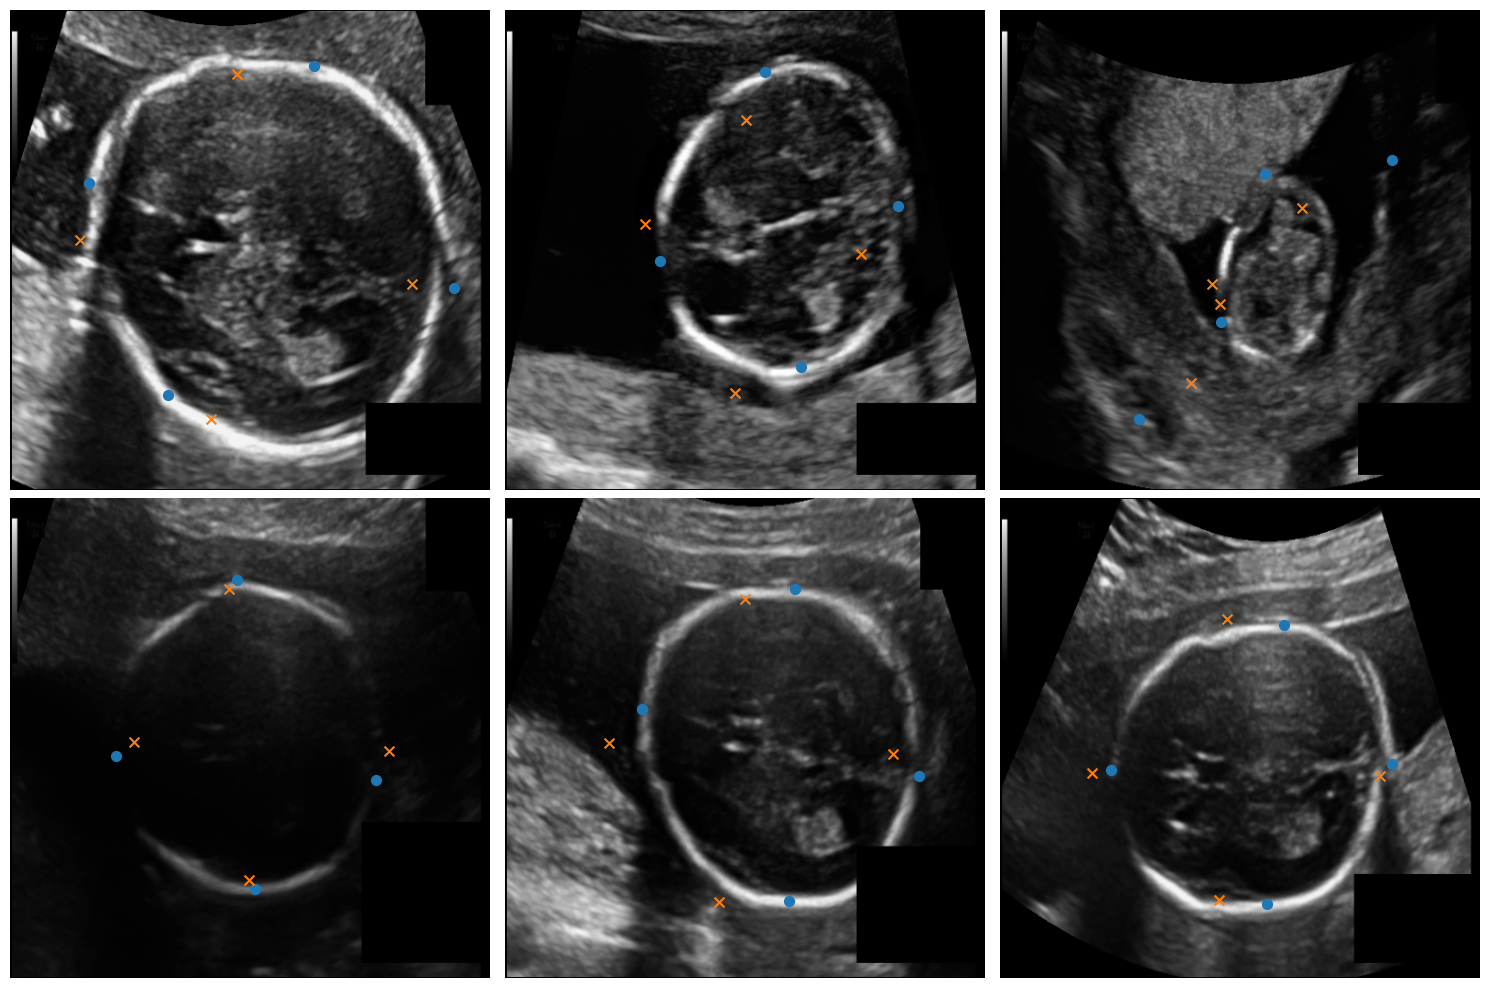

In [ ]:
sample_ids = random.sample(
    range(len(test_dataset_lm)),
    6
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,10)
)

axes = axes.flatten()

for i, idx in enumerate(sample_ids):

    image, gt = test_dataset_lm[idx]

    with torch.no_grad():

        pred = model_lm(
            image.unsqueeze(0).to(DEVICE)
        )

    pred = pred.squeeze().cpu().numpy()

    gt = gt.numpy()

    img = (
        image.permute(1,2,0)
        .cpu()
        .numpy()
    )

    gt_pts = gt.reshape(4,2)

    pred_pts = pred.reshape(4,2)

    gt_pts[:,0] *= 512
    gt_pts[:,1] *= 512

    pred_pts[:,0] *= 512
    pred_pts[:,1] *= 512

    axes[i].imshow(img)

    axes[i].scatter(
        gt_pts[:,0],
        gt_pts[:,1],
        s=50,
        label="GT"
    )

    axes[i].scatter(
        pred_pts[:,0],
        pred_pts[:,1],
        s=50,
        marker="x",
        label="Pred"
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model_lm.load_state_dict(
    torch.load(
        os.path.join(
            SAVE_DIR,
            "landmark_resnet18_best.pth"
        )
    )
)

model_lm.eval()

test_loss = 0
test_error = 0

with torch.no_grad():

    for images, landmarks in test_loader_lm:

        images = images.to(DEVICE)
        landmarks = landmarks.to(DEVICE)

        preds = model_lm(images)

        loss = loss_fn_lm(
            preds,
            landmarks
        )

        test_loss += loss.item()

        test_error += landmark_error(
            preds,
            landmarks
        )

test_loss /= len(test_loader_lm)
test_error /= len(test_loader_lm)

print("Test Loss:", test_loss)
print("Test Error:", test_error)

Test Loss: 0.008855762425810099
Test Error: 0.1370927852888902


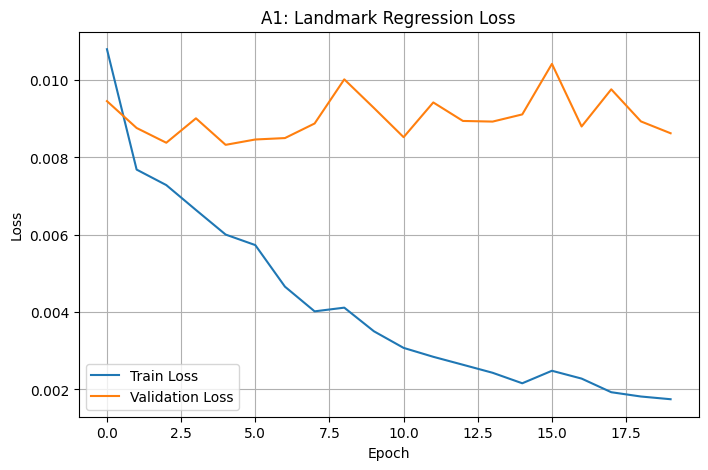

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses_lm,
    label="Train Loss"
)

plt.plot(
    val_losses_lm,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("A1: Landmark Regression Loss")

plt.legend()
plt.grid()

plt.show()

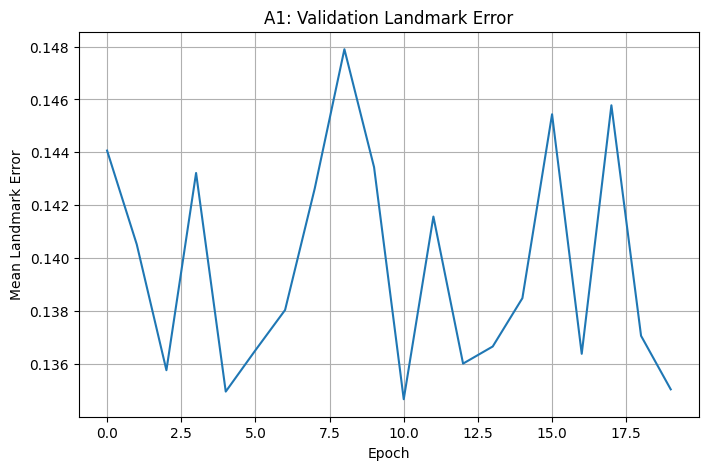

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    val_errors_lm
)

plt.xlabel("Epoch")
plt.ylabel("Mean Landmark Error")

plt.title(
    "A1: Validation Landmark Error"
)

plt.grid()

plt.show()

# Hypothesis A2

## Heatmap-Based Landmark Localization

Observation from A1:

Direct coordinate regression learns global head geometry but does not explicitly model spatial landmark locations.

Hypothesis:

Generating Gaussian heatmaps for each landmark and training a dense prediction network will improve landmark localization accuracy.

Expected Outcome:

More precise landmark predictions and lower localization error compared to direct coordinate regression.

In [ ]:
HEATMAP_SIZE = 128
SIGMA = 3

In [ ]:
import numpy as np

def generate_heatmap(
    x,
    y,
    size=128,
    sigma=3
):

    heatmap = np.zeros(
        (size,size),
        dtype=np.float32
    )

    xx, yy = np.meshgrid(
        np.arange(size),
        np.arange(size)
    )

    heatmap = np.exp(
        -(
            (xx-x)**2
            +
            (yy-y)**2
        ) / (2*sigma**2)
    )

    return heatmap

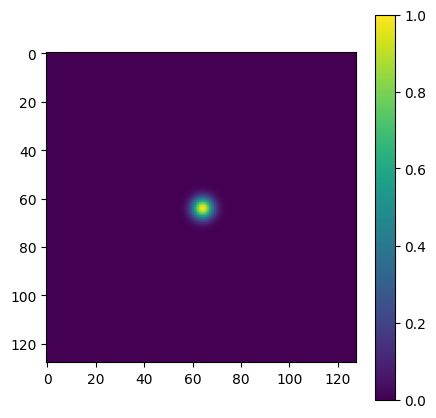

In [ ]:
hm = generate_heatmap(
    64,
    64
)

plt.figure(figsize=(5,5))
plt.imshow(hm)
plt.colorbar()
plt.show()

In [ ]:
class LandmarkHeatmapDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = cv2.imread(
            os.path.join(
                LANDMARK_IMAGE_DIR,
                row["image_name"]
            )
        )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        coords = row[
            LANDMARK_COLUMNS
        ].values.astype(
            np.float32
        )

        coords = coords.reshape(
            4,
            2
        )

        heatmaps = []

        for x, y in coords:

            hm = generate_heatmap(
                x * HEATMAP_SIZE,
                y * HEATMAP_SIZE,
                HEATMAP_SIZE,
                SIGMA
            )

            heatmaps.append(hm)

        heatmaps = np.stack(
            heatmaps,
            axis=0
        )

        if self.transform:

            image = self.transform(
                image=image
            )["image"]

        image = image.float() / 255.0

        heatmaps = torch.tensor(
            heatmaps,
            dtype=torch.float32
        )

        return image, heatmaps

In [ ]:
train_dataset_hm = LandmarkHeatmapDataset(
    train_df_lm,
    landmark_train_transform
)

val_dataset_hm = LandmarkHeatmapDataset(
    val_df_lm,
    landmark_val_transform
)

test_dataset_hm = LandmarkHeatmapDataset(
    test_df_lm,
    landmark_val_transform
)

In [ ]:
train_loader_hm = DataLoader(
    train_dataset_hm,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

val_loader_hm = DataLoader(
    val_dataset_hm,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

test_loader_hm = DataLoader(
    test_dataset_hm,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

In [ ]:
images, heatmaps = next(
    iter(train_loader_hm)
)

print(images.shape)
print(heatmaps.shape)

torch.Size([8, 3, 512, 512])
torch.Size([8, 4, 128, 128])


In [ ]:
import segmentation_models_pytorch as smp
import torch.nn as nn

In [ ]:
model_hm = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4
)

model_hm.to(DEVICE)

print("Model Ready")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Model Ready


In [ ]:
loss_fn_hm = nn.MSELoss()
optimizer_hm = torch.optim.AdamW(
    model_hm.parameters(),
    lr=1e-4
)

In [ ]:
import torch.nn.functional as F
def resize_heatmaps(preds):

    preds = F.interpolate(
        preds,
        size=(128,128),
        mode="bilinear",
        align_corners=False
    )

    return preds

In [ ]:
def heatmap_error(preds, targets):

    batch_size = preds.shape[0]

    errors = []

    preds = resize_heatmaps(preds)

    for b in range(batch_size):

        for c in range(4):

            pred_hm = preds[b,c]

            target_hm = targets[b,c]

            pred_idx = torch.argmax(pred_hm)

            target_idx = torch.argmax(target_hm)

            px = pred_idx % 128
            py = pred_idx // 128

            tx = target_idx % 128
            ty = target_idx // 128

            error = torch.sqrt(
                (px.float()-tx.float())**2 +
                (py.float()-ty.float())**2
            )

            errors.append(
                error.item()
            )

    return np.mean(errors)

In [ ]:
def train_one_epoch_hm():

    model_hm.train()

    running_loss = 0

    for images, heatmaps in train_loader_hm:

        images = images.to(DEVICE)

        heatmaps = heatmaps.to(DEVICE)

        optimizer_hm.zero_grad()

        outputs = model_hm(images)

        outputs = resize_heatmaps(
            outputs
        )

        loss = loss_fn_hm(
            outputs,
            heatmaps
        )

        loss.backward()

        optimizer_hm.step()

        running_loss += loss.item()

    return running_loss / len(train_loader_hm)

In [ ]:
def validate_hm():

    model_hm.eval()

    running_loss = 0
    running_error = 0

    with torch.no_grad():

        for images, heatmaps in val_loader_hm:

            images = images.to(DEVICE)

            heatmaps = heatmaps.to(DEVICE)

            outputs = model_hm(images)

            outputs = resize_heatmaps(
                outputs
            )

            loss = loss_fn_hm(
                outputs,
                heatmaps
            )

            running_loss += loss.item()

            running_error += heatmap_error(
                outputs,
                heatmaps
            )

    return (
        running_loss / len(val_loader_hm),
        running_error / len(val_loader_hm)
    )

In [ ]:
NUM_EPOCHS_HM = 20

best_loss_hm = float("inf")

train_losses_hm = []

val_losses_hm = []

val_errors_hm = []

In [ ]:
for epoch in range(NUM_EPOCHS_HM):

    train_loss = train_one_epoch_hm()

    val_loss, val_error = validate_hm()

    train_losses_hm.append(
        train_loss
    )

    val_losses_hm.append(
        val_loss
    )

    val_errors_hm.append(
        val_error
    )

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS_HM}"
    )

    print(
        f"Train Loss: {train_loss:.6f}"
    )

    print(
        f"Val Loss: {val_loss:.6f}"
    )

    print(
        f"Val Pixel Error: {val_error:.2f}"
    )

    if val_loss < best_loss_hm:

        best_loss_hm = val_loss

        torch.save(
            model_hm.state_dict(),
            os.path.join(
                SAVE_DIR,
                "heatmap_unet_best.pth"
            )
        )

        print("Best A2 model saved")

    print("-"*40)

Epoch 1/20
Train Loss: 0.076623
Val Loss: 0.010722
Val Pixel Error: 88.46
Best A2 model saved
----------------------------------------
Epoch 2/20
Train Loss: 0.006137
Val Loss: 0.003746
Val Pixel Error: 85.99
Best A2 model saved
----------------------------------------
Epoch 3/20
Train Loss: 0.003467
Val Loss: 0.002729
Val Pixel Error: 86.16
Best A2 model saved
----------------------------------------
Epoch 4/20
Train Loss: 0.002756
Val Loss: 0.002363
Val Pixel Error: 84.08
Best A2 model saved
----------------------------------------
Epoch 5/20
Train Loss: 0.002454
Val Loss: 0.002159
Val Pixel Error: 84.19
Best A2 model saved
----------------------------------------
Epoch 6/20
Train Loss: 0.002274
Val Loss: 0.002038
Val Pixel Error: 81.39
Best A2 model saved
----------------------------------------
Epoch 7/20
Train Loss: 0.002157
Val Loss: 0.001974
Val Pixel Error: 76.86
Best A2 model saved
----------------------------------------
Epoch 8/20
Train Loss: 0.002078
Val Loss: 0.001916
Val 

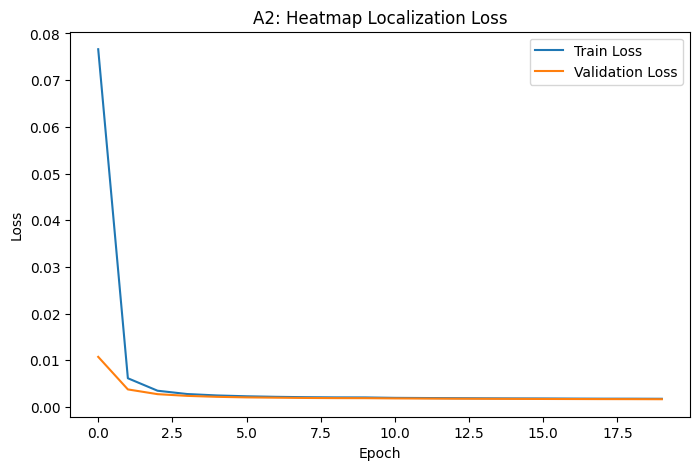

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses_hm,
    label="Train Loss"
)

plt.plot(
    val_losses_hm,
    label="Validation Loss"
)

plt.title("A2: Heatmap Localization Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

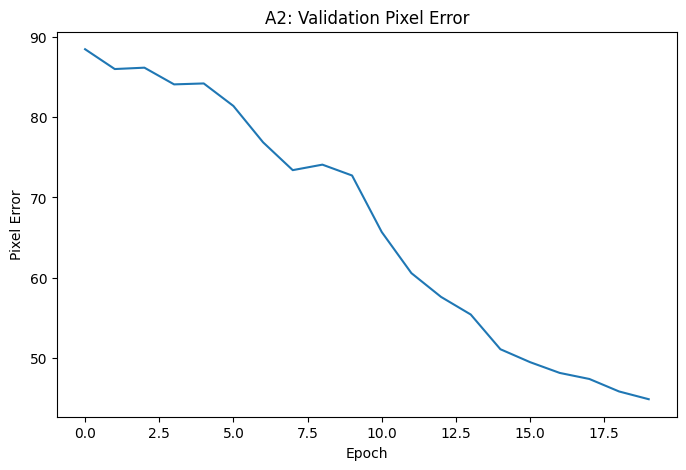

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    val_errors_hm
)

plt.title(
    "A2: Validation Pixel Error"
)

plt.xlabel("Epoch")
plt.ylabel("Pixel Error")

plt.show()

In [ ]:
model_hm.load_state_dict(
    torch.load(
        os.path.join(
            SAVE_DIR,
            "heatmap_unet_best.pth"
        )
    )
)

model_hm.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
images, heatmaps = next(
    iter(val_loader_hm)
)

images = images.to(DEVICE)

with torch.no_grad():

    preds = model_hm(images)

preds = resize_heatmaps(preds)

preds = preds.cpu()

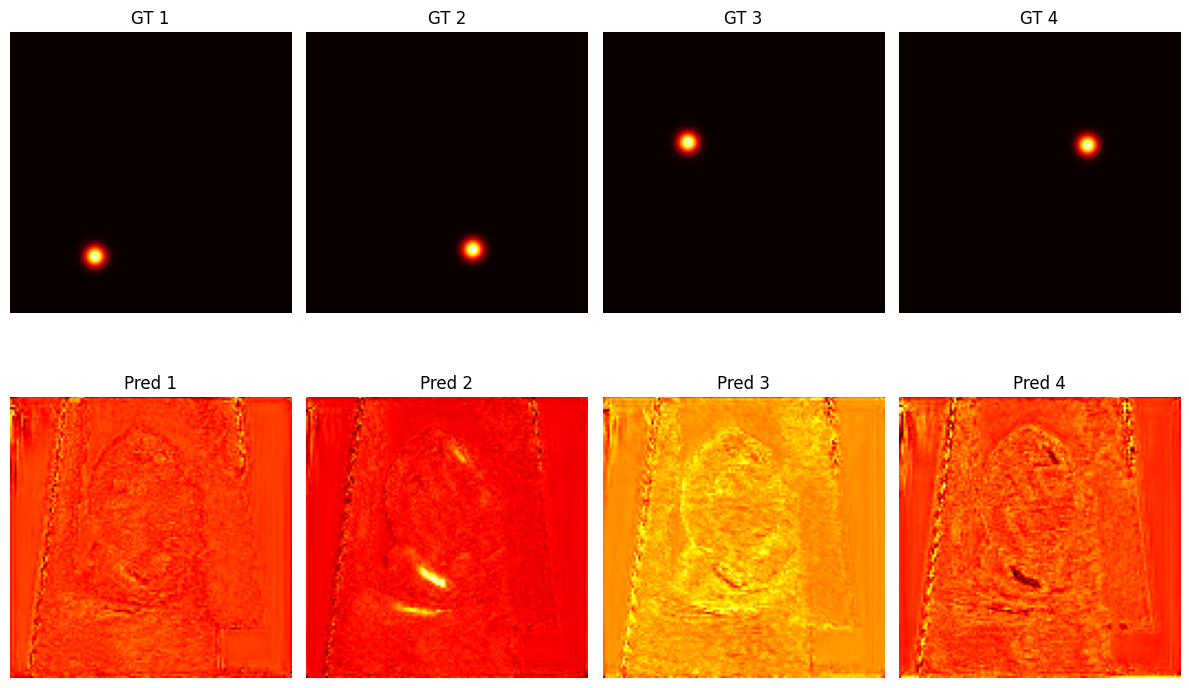

In [ ]:
sample = 0

plt.figure(figsize=(12,8))

for i in range(4):

    plt.subplot(2,4,i+1)

    plt.imshow(
        heatmaps[sample,i],
        cmap="hot"
    )

    plt.title(
        f"GT {i+1}"
    )

    plt.axis("off")

    plt.subplot(2,4,i+5)

    plt.imshow(
        preds[sample,i],
        cmap="hot"
    )

    plt.title(
        f"Pred {i+1}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def validate_hm(model, loader):

    model.eval()

    running_loss = 0
    running_error = 0

    with torch.no_grad():

        for images, heatmaps in loader:

            images = images.to(DEVICE)
            heatmaps = heatmaps.to(DEVICE)

            outputs = model(images)

            outputs = resize_heatmaps(outputs)

            loss = loss_fn_hm(
                outputs,
                heatmaps
            )

            running_loss += loss.item()

            running_error += heatmap_error(
                outputs,
                heatmaps
            )

    return (
        running_loss / len(loader),
        running_error / len(loader)
    )

In [ ]:
test_loss, test_error = validate_hm(
    model_hm,
    test_loader_hm
)

print("Test Loss:", test_loss)
print("Test Pixel Error:", test_error)

Test Loss: 0.001653032872127369
Test Pixel Error: 43.78446639629288


### Result

Although the heatmap model achieved a low validation loss,
visual inspection revealed that the predicted heatmaps were
diffuse and failed to form strong localized peaks around the
target landmarks.

The validation pixel error remained substantially larger
than the coordinate regression baseline.

Therefore, the heatmap localization approach did not outperform
direct coordinate regression on the available dataset.

# Results Summary

## Part A

### A1: Coordinate Regression
- Test Error: 0.137

### A2: Heatmap Localization
- Test Pixel Error: 43.78 pixels

Conclusion:
Coordinate regression provided more accurate landmark localization than heatmap regression on the available dataset.

---

## Part B

### H1: Contour Mask Segmentation
- Test Dice: 0.26

### H2: Filled Mask Segmentation
- Test Dice: 0.977

Conclusion:
Filled cranial masks significantly improved segmentation performance by mitigating extreme class imbalance.

---

## Final Segmentation-Based Biometry Extraction

The best segmentation model was used to generate cranial masks. An ellipse was fitted to the predicted mask and the major/minor axes were extracted to estimate OFD and BPD measurements automatically.

In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/Origin_Medical_Challenge/models"

print(os.listdir(SAVE_DIR))

['unet_resnet34_best.pth', 'hypothesis2_filledmask_unet_resnet34.pth', 'H2_loss_curve.png', 'H2_dice_curve.png', 'H2_predictions.png', 'segmentation_results.csv', 'landmark_resnet18_best.pth', 'heatmap_unet_best.pth']
